# HCNNG

In [ ]:
# One-time Build HCNNG

cd hcnng
g++ hcnng.cpp -o hcnng -std=c++11 -fopenmp -O3
g++ search.cpp -o search -std=c++11 -fopenmp -O3

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

def plot_all_combinations(
    base_dir: str, 
    filter_n: list = None, 
    filter_m: list = None, 
    topk: int = 100, 
    max_calc_list: list = None,
    metric: str = "Recall@100",  # 可选 "Recall@100" 或 "MRR@100"
    save_fig: bool = True
):
    """
    在同一个图上绘制 HCNNG 所有 (n, m) 组合的 QPS vs 指定指标 曲线。

    参数:
        base_dir (str): 包含 n*_m* 子目录的根目录（例如 ./hcnng）
        filter_n (list, optional): 只绘制 n 值在此列表中的组合，如 [500, 1000]
        filter_m (list, optional): 只绘制 m 值在此列表中的组合，如 [20, 30]
        topk (int): 要显示的 K 值（默认 100）
        max_calc_list (list, optional): 只绘制 max_calc 在此列表中的点
        metric (str): 要绘制的指标，可选 "Recall@100" 或 "MRR@100"
        save_fig (bool): 是否保存图片到 base_dir
    """
    # 收集所有符合条件的组合目录
    combo_dirs = []
    for item in os.listdir(base_dir):
        full_path = os.path.join(base_dir, item)
        if not os.path.isdir(full_path):
            continue
        match = re.match(r"n(\d+)_m(\d+)", item)
        if not match:
            continue
        n_val = int(match.group(1))
        m_val = int(match.group(2))

        # 应用过滤条件
        if filter_n is not None and n_val not in filter_n:
            continue
        if filter_m is not None and m_val not in filter_m:
            continue

        # 检查是否存在 summary.csv
        csv_path = os.path.join(full_path, "summary.csv")
        if os.path.isfile(csv_path):
            combo_dirs.append((n_val, m_val, csv_path))
        else:
            print(f"警告: {full_path} 中缺少 summary.csv，跳过")

    if not combo_dirs:
        print("未找到任何有效的组合数据，请检查 base_dir 和过滤条件。")
        return

    print(f"找到 {len(combo_dirs)} 个组合: {[(n,m) for n,m,_ in combo_dirs]}")

    # 设置绘图风格
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size'] = 12

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # 颜色循环
    colors = plt.cm.tab20(np.linspace(0, 1, len(combo_dirs)))

    for idx, (n_val, m_val, csv_path) in enumerate(combo_dirs):
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"读取 {csv_path} 失败: {e}")
            continue

        # 过滤 K
        if topk is not None:
            df = df[df['K'] == topk]
        # 过滤 max_calc
        if max_calc_list is not None:
            df = df[df['max_calc'].isin(max_calc_list)]

        if df.empty:
            print(f"组合 n={n_val}, m={m_val} 无有效数据点，跳过")
            continue

        # 按 QPS 排序
        df_sorted = df.sort_values("QPS")

        # 提取指标列，如果指标不存在则尝试 fallback
        if metric not in df_sorted.columns:
            print(f"警告: {metric} 不存在于 {csv_path}，尝试使用 Recall@100")
            metric_used = "Recall@100"
            if metric_used not in df_sorted.columns:
                print(f"错误: 无法找到任何有效指标，跳过组合 n={n_val}, m={m_val}")
                continue
        else:
            metric_used = metric

        # 绘制曲线
        label = f"n={n_val}, m={m_val}"
        ax.plot(
            df_sorted["QPS"], 
            df_sorted[metric_used], 
            marker='o', 
            linestyle='-', 
            linewidth=2, 
            markersize=6,
            color=colors[idx % len(colors)],
            label=label
        )

        # 标注每个点（可选，如果点太多可注释掉）
        # for _, row in df_sorted.iterrows():
        #     ax.annotate(f"{row['max_calc']}", 
        #                 xy=(row["QPS"], row[metric_used]),
        #                 xytext=(3, 3), textcoords='offset points', fontsize=8)

    ax.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax.set_ylabel(metric_used, fontsize=14)
    ax.set_title(f"QPS vs {metric_used} (Top-{topk})", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='best', fontsize=10)

    # 对数坐标 (可选)
    ax.set_xscale('log')
    ax.set_xticks([1, 10, 100, 1000, 10000])
    ax.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$'])

    plt.tight_layout()

    if save_fig:
        # 生成文件名（包含过滤信息）
        fname = "combined_plot"
        if filter_n:
            fname += f"_n{'_'.join(map(str, filter_n))}"
        if filter_m:
            fname += f"_m{'_'.join(map(str, filter_m))}"
        if max_calc_list:
            fname += f"_maxcalc_{min(max_calc_list)}_{max(max_calc_list)}"
        fname += ".png"
        save_path = os.path.join(base_dir, fname)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存至: {save_path}")

    plt.show()

--- 

## Clerc-large

In [ ]:
# first prepare data (1000 query)

cd svr-baselines

mkdir -p /data/ali/baseline-data/clerc-large-single/inputs
mkdir -p /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hcnng
mkdir -p /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hnswlib
mkdir -p /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/logs

python3 /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/prepare_clerc_large_single.py \
  --dataset-dir </data/ali/clerc-large-single> \
  --output-dir </data/ali/baseline-data/clerc-large-single/inputs> \
  --num-queries 1000 \
  --dataset-prefix clerc-large-single

In [ ]:
# HCNNG index build

/data1/chenyifeng/MultiVector-Backup/svr-baselines/hcnng/hcnng \
  /data/ali/clerc-large-single/clerc-large-single_base.fvecs \
  1000 \
  20 \
  /data/ali/baseline-data/clerc-large-single/hcnng/index.ivecs

In [ ]:
# HCNNG query run

/data1/chenyifeng/MultiVector-Backup/svr-baselines/hcnng/search \
  /data/ali/clerc-large-single/clerc-large-single_base.fvecs \
  /data/ali/baseline-data/clerc-large-single/inputs/query_1000.fvecs \
  /data/ali/baseline-data/clerc-large-single/inputs/groundtruth_1000.ivecs \
  /data/ali/baseline-data/clerc-large-single/hcnng/index.ivecs \
  100 \
  2000 \
  /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hcnng/ans_k100_scored.tsv \
  /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hcnng/qps_k100_scored.tsv \
  > /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/logs/hcnng_k100_scored.log 2>&1


Important parameter:

- `max_calc=2000`
  - this is HCNNG's search budget
  - it limits how many vectors are explored / distance calculations are spent per query
  - larger `max_calc` usually improves recall and lowers QPS

In [ ]:
# HCNNG Evaluate Recall@10 and Recall@100

# python3 /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/eval_recall.py \
  # --groundtruth /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/inputs/groundtruth_1000.ivecs \
  # --results /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/ans_k100_scored.tsv \
  # --k 10

# python3 /home/ali/SVR-baselines/runs/eval_recall.py \
  # --groundtruth /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/inputs/groundtruth_1000.ivecs \
  # --results /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/ans_k100_scored.tsv \
  # --k 100


In [ ]:
# BEIR-style evaluation

python3 /home/ali/SVR-baselines/runs/eval_beir_metrics.py \
  --groundtruth /data/ali/baseline-data/clerc-large-single/inputs/groundtruth_1000.ivecs \
  --results /home/ali/SVR-baselines/runs/clerc-large-single/hcnng/ans_k100_scored.tsv \
  --k-values 1 3 5 10 100 \
  --output-json /home/ali/SVR-baselines/runs/clerc-large-single/hcnng/beir_metrics_k100_scored.json



In [ ]:
# HCNNG QPS

# already write

/home/ali/SVR-baselines/runs/clerc-large-single/hcnng/qps_k100_scored.tsv

## Scidocs

默认 n=1000, m=20

search thread 可调

In [ ]:
cd svr-baselines

bash hcnng_scidocs.sh

找到 8 个组合: [(1000, 30), (1000, 5), (1500, 30), (1000, 10), (1500, 5), (1500, 20), (1000, 20), (1500, 10)]
图片已保存至: /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/combined_plot_n1000_1500_m5_10_20_30.png


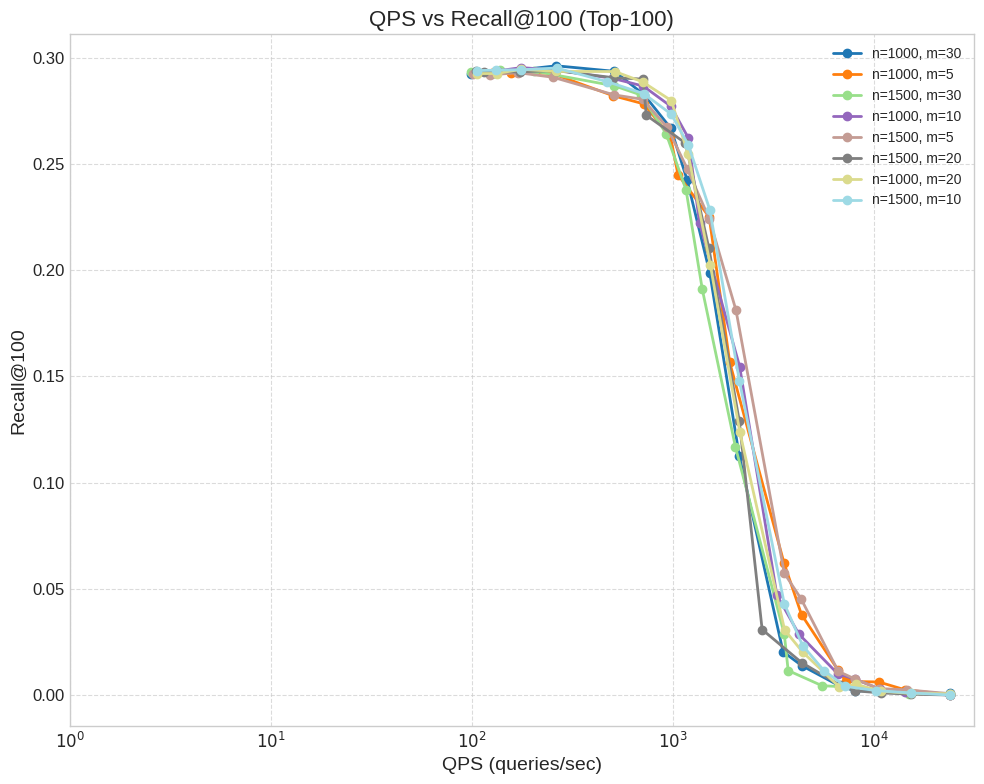

In [6]:
plot_all_combinations(
    base_dir="/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng",
    filter_n=[1000, 1500],
    filter_m=[5, 10 ,20, 30],
)

# 1000 30

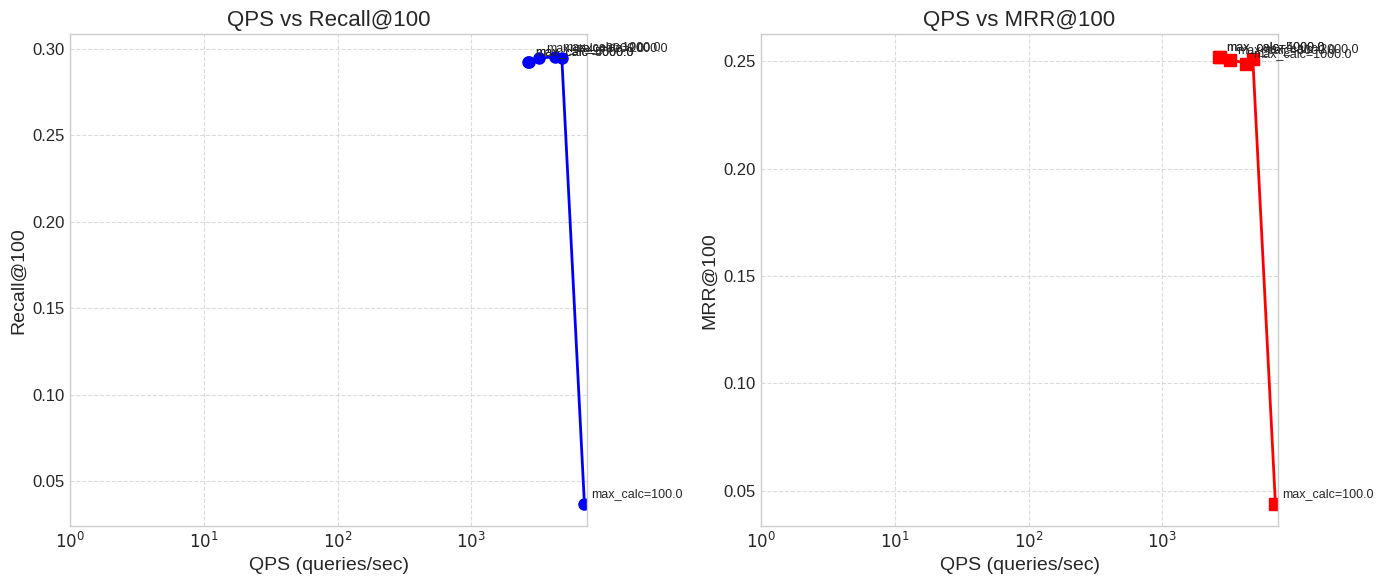

图片已保存为 '/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/summary.png'


In [6]:
# plot 

plot_qps_metrics("/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/summary.csv", 
                 topk=100, 
                 max_calc_list=[100, 1000, 2000, 3000, 4000, 5000])

## Fiqa

In [ ]:
cd svr-baselines

# 默认test-embedding顺序与
# gt.ivecs的顺序需与

bash hcnng_fiqa.sh

In [7]:
# summary

extract_hcnng_metrics(base_dir="/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hcnng")

汇总结果已保存至: /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hcnng/summary.csv


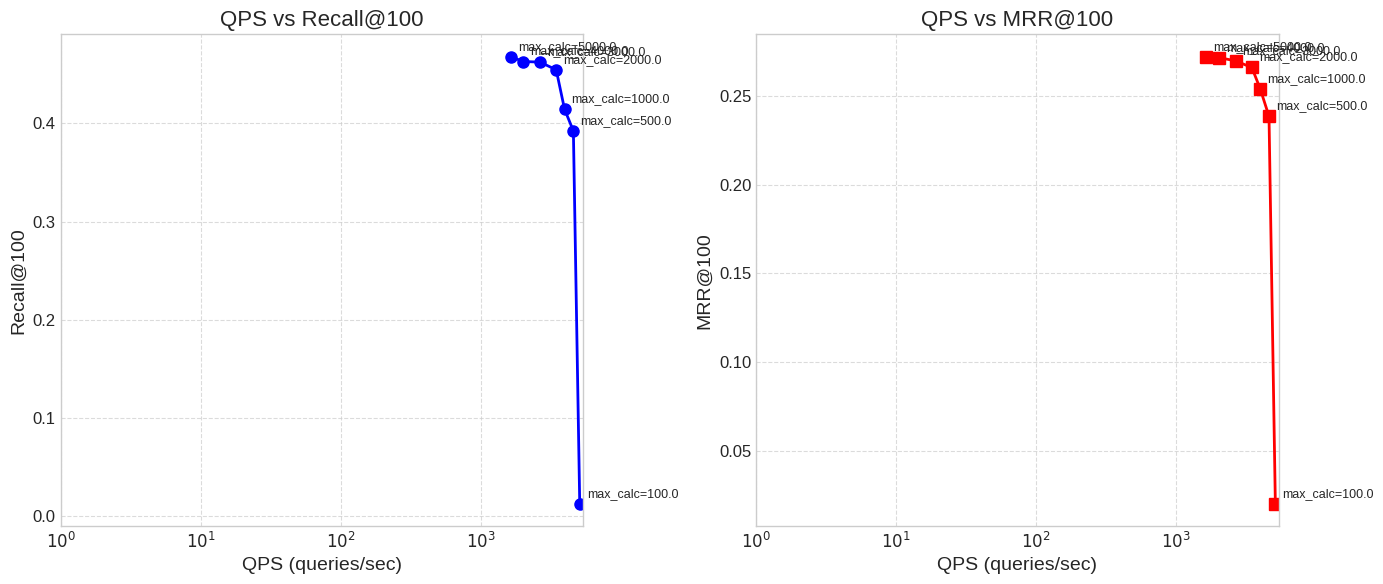

图片已保存为 '/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hcnng/summary.png'


In [9]:
# plot 

plot_qps_metrics("/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hcnng/summary.csv", 
                 topk=100, 
                 max_calc_list=[100, 500, 1000, 2000, 3000, 4000, 5000])